# **1. 라이브러리 Import**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 재현성을 위한 seed 설정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# **2. 데이터 준비**

### (1) 데이터 로드
### (2) 컬럼 분류
- key_cols = ['year', 'country', 'admin']
- target_col = 'infection_rate'
- climate_cols = ['max_temperature', 'min_temperature', 'avg_temperature']
- livestock_cols = ['Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
- landuse_cols = ['rate_landuse']
### (3) X, y 분리
### (4) Feature scaling
- climate : standard scaling
- livestock, landuse : log transformation + standard scaling

In [3]:
# 데이터 로드
df = pd.read_csv('../data/processed/cleaned_disease_dataset_2015landuse.csv')

print(f"Total samples: {len(df):,}")
df.head()

Total samples: 473


,year,country,admin,infection_rate,max_temperature,min_temperature,avg_temperature,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse,missing_ratio
0,2010,Burkina Faso,Boucle Du Mouhoun,0.585652,307.42114,297.76172,302.50760,0.0,25.000049,164.065700,0.0,34.153420,0.693863,21.774243,9.682960,0.076206,0.0
1,2010,Burkina Faso,Cascades,0.979432,304.47192,297.88160,300.27893,0.0,38.008688,96.864817,0.0,12.506484,0.008877,12.373391,3.865450,0.074387,0.0
2,2010,Burkina Faso,Centre,1.955671,307.73170,299.50660,302.80447,0.0,17.566445,303.908919,0.0,58.134766,0.019041,40.947445,6.821150,0.407856,0.0
3,2010,Burkina Faso,Centre-est,1.037736,307.41138,298.78003,302.61942,0.0,29.597071,203.094681,0.0,69.010943,0.027864,45.871831,18.292361,0.143950,0.0
4,2010,Burkina Faso,Centre-nord,0.379147,308.31274,297.82104,303.14368,0.0,28.843678,138.295650,0.0,65.134086,0.079677,48.346972,4.834737,0.120649,0.0


In [4]:
# 컬럼 분류
key_cols = ['year', 'country', 'admin']
target_col = 'infection_rate'
climate_cols = ['max_temperature', 'min_temperature', 'avg_temperature']
livestock_cols = ['Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
landuse_cols = ['rate_landuse']
feature_cols = climate_cols + livestock_cols + landuse_cols

print(f"Feature 컬럼 ({len(feature_cols)}개): {feature_cols}")
print(f"Target 컬럼: {target_col}")

Feature 컬럼 (12개): ['max_temperature', 'min_temperature', 'avg_temperature', 'Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine', 'rate_landuse']
Target 컬럼: infection_rate


In [5]:
# X, y 분리
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (473, 12)
y shape: (473,)


In [6]:
# Feature(X) scaling
X_scaled = X.copy()

# Climate : standard normal dist 
# #         => standard scaling
standard_cols = climate_cols
scaler_climate = StandardScaler()
X_scaled[climate_cols] = scaler_climate.fit_transform(X_scaled[climate_cols])

# Livestock, Landuse : right-skewed dist
#                      => log transformation + standard scaling
skewed_cols = livestock_cols + landuse_cols
for col in skewed_cols:
    X_scaled[col] = np.log1p(X_scaled[col])

scaler_skewed = StandardScaler()
X_scaled[skewed_cols] = scaler_skewed.fit_transform(X_scaled[skewed_cols])

In [7]:
print("=== Scaling 전후 비교 ===")
# df에서 mean()을 한 번 취하면 컬럼별 평균이, 두 번 취하면 컬럼 평균의 평균(전체 평균)이 구해짐

print("\n[Scaling 전]")
print(f"평균: {X.mean().mean():.4f}, 표준편차: {X.std().mean():.4f}")

print("\n[Scaling 후]")
print(f"평균: {X_scaled.mean().mean():.4f}, 표준편차: {X_scaled.std().mean():.4f}")

=== Scaling 전후 비교 ===

[Scaling 전]
평균: 97.1898, 표준편차: 76.4891

[Scaling 후]
평균: 0.0000, 표준편차: 0.9176


In [8]:
# train, test dataset 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)

print("=== Random Split ===")
print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain - y 평균: {y_train.mean():.4f}, 표준편차: {y_train.std():.4f}")
print(f"Test - y 평균: {y_test.mean():.4f}, 표준편차: {y_test.std():.4f}")

=== Random Split ===
Train set: 378 samples (79.9%)
Test set: 95 samples (20.1%)

Train - y 평균: 5.5219, 표준편차: 6.7059
Test - y 평균: 5.0191, 표준편차: 6.1762


# **3. PCA 진행**

In [9]:
pca = PCA(n_components= 10)
principalComponents = pca.fit_transform(X_train)
principalDf = pd.DataFrame(data=principalComponents, columns = ['principal component1', 'principal component2', '3','4','5','6','7','8','9','10'])
print(pca.explained_variance_ratio_)

principalDf

[0.30858278 0.26709626 0.1391547  0.09928429 0.05564953 0.04153926
 0.03214133 0.02294816 0.01981735 0.01322578]


,principal component1,principal component2,3,4,5,6,7,8,9,10
0,-1.361908,0.338825,-2.169809,-0.461508,-0.243074,0.817005,-0.655141,0.530527,-1.764164,0.293988
1,0.211383,2.094929,0.467380,-0.692651,0.376629,0.331493,-0.239140,-0.554830,-0.602953,-0.010677
2,0.030740,-0.930839,0.630018,-0.445570,-0.117385,-0.312753,1.004076,0.748580,-0.064156,0.419534
3,0.997370,2.850826,0.613499,-0.647684,0.897670,0.663495,0.447844,0.660038,-0.566038,-0.310022
4,3.772987,-0.082534,3.160653,-1.022098,-0.146682,-0.961161,-0.447447,0.173087,-0.319957,-0.632838
...,...,...,...,...,...,...,...,...,...,...
373,4.401134,-0.827907,-0.914919,0.193862,-1.642518,-2.572990,-1.178647,0.100790,0.402901,-0.687141
374,-0.416984,-0.777571,-0.459941,-0.540194,-0.937560,-0.063212,-0.862266,1.239215,0.382779,0.934406
375,-3.626943,0.329617,-0.713350,-0.160171,-0.302193,-0.029589,-1.066304,0.529077,-0.043167,-0.385331
376,-0.871584,-0.733671,0.488216,-0.232914,0.246168,-0.065882,0.132918,-0.325237,0.425820,0.210618


## **3-1. 주성분 해석률 분석**

### 3-1-1. 주성분 설명률
- x : 주성분(1순위 ~ 10순위)
- y : 설명률

Text(0, 0.5, 'Explained %')

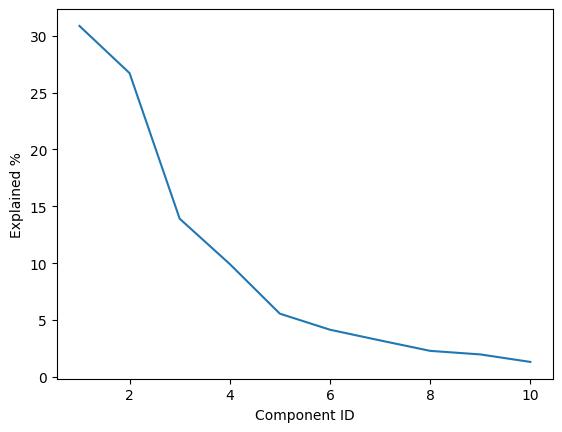

In [12]:
plt.plot(np.arange(1, 11), pca.explained_variance_ratio_ * 100)
plt.xlabel("Component ID")
plt.ylabel("Explained %")

### 3-1-2. 주성분 누적 설명률
- x : 주성분(1순위 ~ 10순위)
- y : 설명률

Text(0, 0.5, 'Explained %')

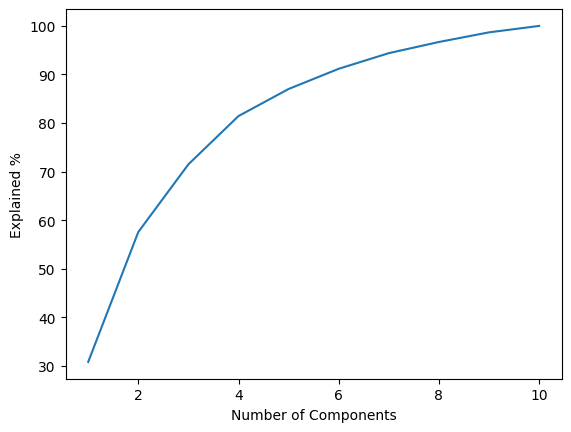

In [13]:
plt.plot(np.arange(1, 11), np.cumsum(pca.explained_variance_ratio_) * 100)
plt.xlabel("Number of Components")
plt.ylabel("Explained %")

- PC1: 30.8%
- PC1 + PC2: 57.5%
- PC1 + PC2 + PC3: 71.4%
- **PC1 + PC2 + PC3 + PC4: 81.4%**
    
    ⇒ **4개의 주성분(PC1~4)만 사용해도 전체 데이터 정보량의 81.4%를 설명**할 수 있음

## **3-2. 시각화**
: PC1, PC2 축으로 산점도(Scatter plot) 그리기
체크 포인트
- 군집
- 이상치
- Target(label)구분(라벨에 따라 색을 다르게 칠해서 잘 나뉜다면 분류가 잘 될 것이라고 봄)

### 3-2-1. target이 infectionrate일 때

=== Final DataFrame for Visualization ===
   principal component1  principal component2         3         4         5  \
0             -1.361908              0.338825 -2.169809 -0.461508 -0.243074   
1              0.211383              2.094929  0.467380 -0.692651  0.376629   
2              0.030740             -0.930839  0.630018 -0.445570 -0.117385   
3              0.997370              2.850826  0.613499 -0.647684  0.897670   
4              3.772987             -0.082534  3.160653 -1.022098 -0.146682   

          6         7         8         9        10  infection_rate  
0  0.817005 -0.655141  0.530527 -1.764164  0.293988        0.694444  
1  0.331493 -0.239140 -0.554830 -0.602953 -0.010677        0.932091  
2 -0.312753  1.004076  0.748580 -0.064156  0.419534       13.944099  
3  0.663495  0.447844  0.660038 -0.566038 -0.310022        1.274313  
4 -0.961161 -0.447447  0.173087 -0.319957 -0.632838        4.628949  


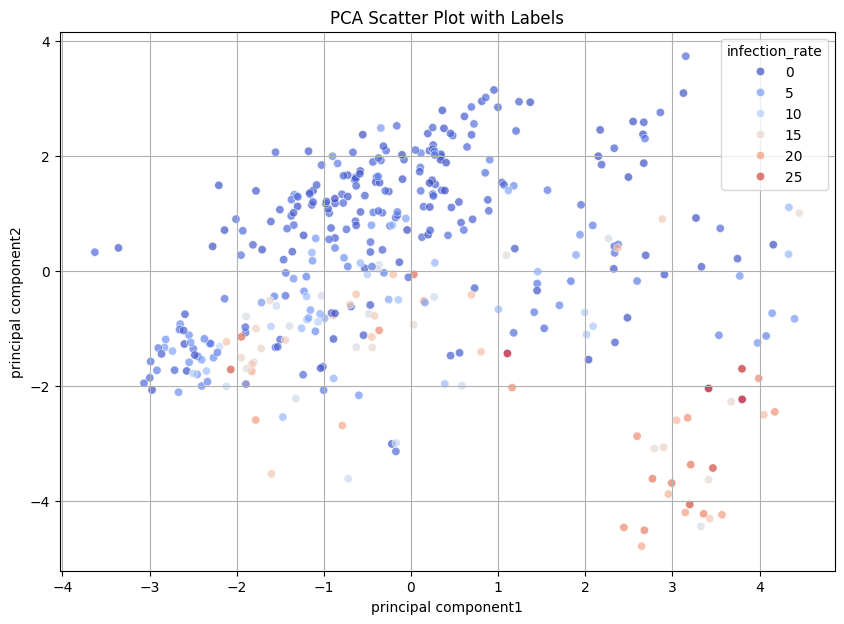

In [10]:
# 1. y_train의 인덱스를 0부터 다시 매기기 (필수!)
# reset_index(drop=True)를 해야 기존 인덱스가 컬럼으로 안 남고 깔끔해집니다.
y_train_reset = y_train.reset_index(drop=True)

# 2. PCA 결과(X)와 라벨(y)을 가로로 이어 붙이기
finalDf = pd.concat([principalDf, y_train_reset], axis=1)

# 합쳐진 데이터 확인 (디버깅용)
print("=== Final DataFrame for Visualization ===")
print(finalDf.head())

# 3. 시각화 (PC1 vs PC2)
plt.figure(figsize=(10, 7))

# y_train이 'infection_rate' 같은 연속형 숫자라면 색이 그라데이션으로 표현되고,
# 'High/Low' 같은 범주형이라면 색깔이 구분되어 표현됩니다.
sns.scatterplot(
    data=finalDf, 
    x='principal component1', 
    y='principal component2', 
    hue=y_train.name,  # y_train의 컬럼명을 자동으로 가져옴
    palette='coolwarm', # 색상 테마 (숫자면 viridis, 분류면 set2 추천)
    alpha=0.7        # 점 투명도
)

plt.title('PCA Scatter Plot with Labels')
plt.grid(True)
plt.show()

### 3-2-2. target을 infection 위험등급(class 부여)일 때

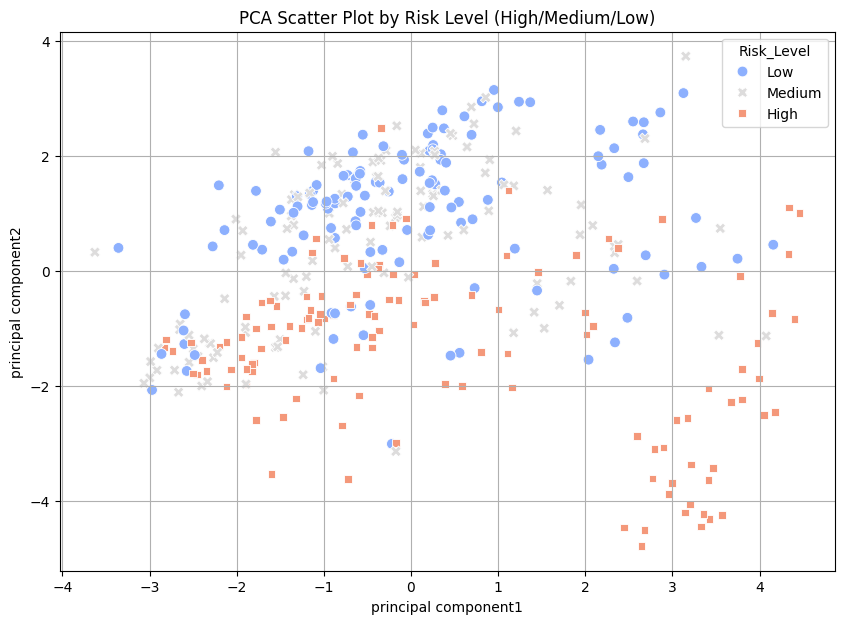

In [ ]:
#1. 시각화용 데이터프레임 복사 (원본 보존)
plot_df = finalDf.copy()

# 2. y값(infection_rate)을 3개의 등급으로 나누기 (Quantile cut)
# q=3은 3등분 (Low, Medium, High), labels는 등급 이름
# y_train.name 대신 실제 컬럼명(예: 'infection_rate')을 쓰셔도 됩니다.
target_col = y_train.name 
plot_df['Risk_Level'] = pd.qcut(plot_df[target_col], q=3, labels=['Low', 'Medium', 'High'])

# 3. 변경된 데이터로 산점도 그리기
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df, 
    x='principal component1', 
    y='principal component2', 
    hue='Risk_Level',      # 여기서 방금 만든 등급 컬럼을 지정
    palette='coolwarm',        # 빨/파/초 처럼 확연히 다른 색상표 사용
    style='Risk_Level',    # 모양(O, X, ㅁ)도 다르게 하면 더 잘 보임
    s=60,                   # 점 크기 키우기
    alpha=1
)

plt.title('PCA Scatter Plot by Risk Level (High/Medium/Low)')
plt.grid(True)
plt.show()

## 3-3. PC 의미 분석
PCA Loadings(고유벡터) 분석을 통해 주성분 벡터의 의미를 파악

In [54]:
# 로딩 매트릭스 계산
loading_matrix = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
    index=X_train.columns
)

final_loading_matrix = loading_matrix[['PC1','PC2','PC3','PC4']]

final_loading_matrix


,PC1,PC2,PC3,PC4
max_temperature,-2.860074e-01,4.661510e-01,-1.715815e-01,-4.421760e-02
min_temperature,-3.085775e-01,4.540561e-01,1.963322e-01,9.573418e-02
avg_temperature,-3.219451e-01,4.984318e-01,-1.727506e-02,3.725071e-02
Buffa,1.110223e-16,5.551115e-17,2.775558e-17,-1.387779e-17
Cattl,3.702071e-01,2.388762e-01,-1.891527e-01,-1.895303e-01
Chick,2.317717e-01,2.999765e-01,3.442417e-01,1.462604e-01
Ducks,4.077862e-02,1.207805e-02,1.912213e-01,7.440922e-01
Goats,3.821024e-01,3.056179e-01,-1.108262e-01,-1.693138e-01
Horse,2.721385e-01,4.716788e-02,-4.123549e-01,5.794749e-01
Sheep,3.639332e-01,2.649335e-01,-3.377720e-01,-5.545408e-02


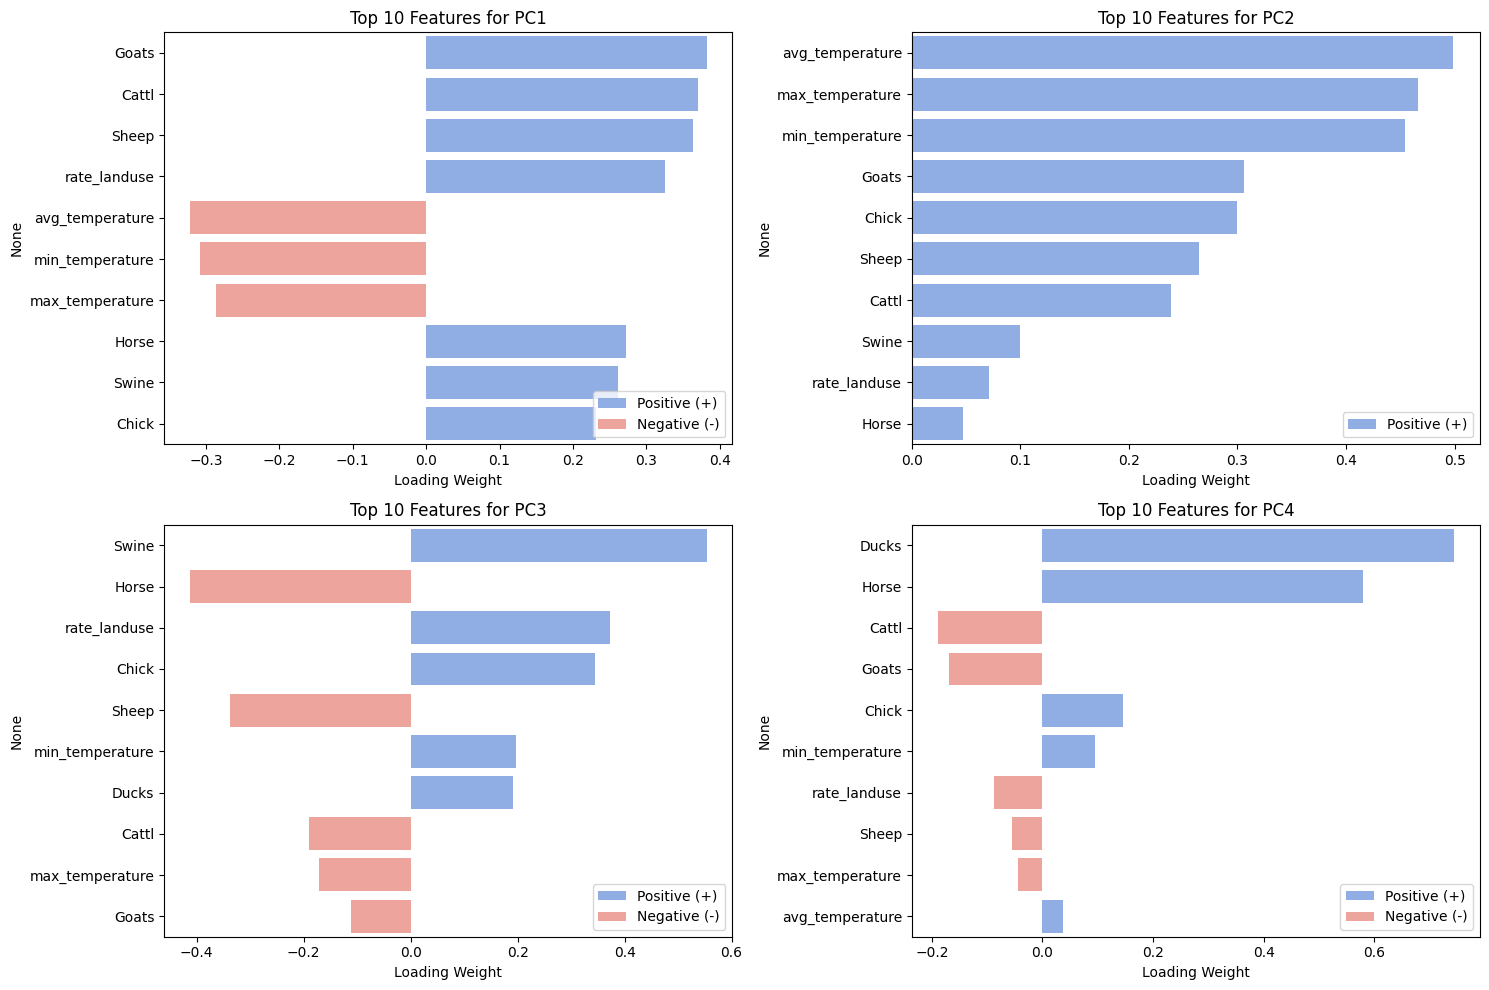

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, pc_col in enumerate(final_loading_matrix.columns[:4]):
    
    # 절대값 기준 Top 10 뽑기
    top_10 = final_loading_matrix[pc_col].iloc[
        final_loading_matrix[pc_col].abs().argsort()[::-1]
    ][:10]
    
   
    df_plot = top_10.to_frame(name='Weight') # Series를 DataFrame으로
    df_plot['Sign'] = np.where(df_plot['Weight'] > 0, 'Positive (+)', 'Negative (-)')
    
    
    sns.barplot(
        data=df_plot,
        x='Weight',
        y=df_plot.index,
        ax=axes[i],
        hue='Sign',          
        palette={'Positive (+)': 'cornflowerblue', 'Negative (-)': 'salmon'},
        dodge=False,         
        alpha=0.8
    )
    
    axes[i].set_title(f'Top 10 Features for {pc_col}')
    axes[i].set_xlabel('Loading Weight')
    
    # 범례가 그래프마다 생기면 지저분하니까 필요하면 위치 조정하거나 끄기
    axes[i].legend(loc='lower right') 

plt.tight_layout()
plt.show()

In [62]:
for i in range(len(final_loading_matrix.columns)):
    column_name = final_loading_matrix.columns[i]
    #col_df = loading_matrix[column_name]
    
    # 분석용 임시 데이터프레임 생성
    pc_analysis = final_loading_matrix[[column_name]].copy()
    # 'abs_weight'라는 컬럼에 절댓값 저장 (정렬용)
    pc_analysis['importance'] = pc_analysis[column_name].abs()
    # 중요도(importance) 순으로 내림차순 정렬
    result = pc_analysis.sort_values(by='importance', ascending=False)
    
    # 상위 10개 출력
    print("----", column_name, "의 변수 기여도----")
    print(result.head(10))
    print("\n\n")
    

---- PC1 의 변수 기여도----
                      PC1  importance
Goats            0.382102    0.382102
Cattl            0.370207    0.370207
Sheep            0.363933    0.363933
rate_landuse     0.325316    0.325316
avg_temperature -0.321945    0.321945
min_temperature -0.308577    0.308577
max_temperature -0.286007    0.286007
Horse            0.272139    0.272139
Swine            0.261835    0.261835
Chick            0.231772    0.231772



---- PC2 의 변수 기여도----
                      PC2  importance
avg_temperature  0.498432    0.498432
max_temperature  0.466151    0.466151
min_temperature  0.454056    0.454056
Goats            0.305618    0.305618
Chick            0.299977    0.299977
Sheep            0.264933    0.264933
Cattl            0.238876    0.238876
Swine            0.099890    0.099890
rate_landuse     0.071510    0.071510
Horse            0.047168    0.047168



---- PC3 의 변수 기여도----
                      PC3  importance
Swine            0.553210    0.553210
Horse           

In [ ]:
top_n = 5
summary_data = {}

for col in final_loading_matrix.columns[:4]: # PC1 ~ PC4
    # 절댓값 기준 정렬 후 상위 N개 인덱스(변수명)와 값 가져오기
    top_features = final_loading_matrix[col].iloc[
        final_loading_matrix[col].abs().argsort()[::-1]
    ][:top_n]
    
    # 딕셔너리에 저장 (변수명과 기여도를 따로 저장)
    summary_data[f'{col}_Feature'] = top_features.index.tolist()
    summary_data[f'{col}_Value'] = top_features.values.round(3) # 소수점 3자리 반올림

# 결과를 DataFrame으로 변환
summary_df = pd.DataFrame(summary_data)

# 출력
print("=== PC별 기여도 높은 주요 변수 요약 ===")
display(summary_df)

=== PC별 기여도 높은 주요 변수 요약 ===


,PC1_Feature,PC1_Value,PC2_Feature,PC2_Value,PC3_Feature,PC3_Value,PC4_Feature,PC4_Value
0,Goats,0.382,avg_temperature,0.498,Swine,0.553,Ducks,0.744
1,Cattl,0.370,max_temperature,0.466,Horse,-0.412,Horse,0.579
2,Sheep,0.364,min_temperature,0.454,rate_landuse,0.372,Cattl,-0.190
3,rate_landuse,0.325,Goats,0.306,Chick,0.344,Goats,-0.169
4,avg_temperature,-0.322,Chick,0.300,Sheep,-0.338,Chick,0.146


## 3-4. Biplot
biplot은 PCA 분석에서 찾은 주성부과 원데이터 변수 간의 상관관계를 보여주는 그래프

- 각 PC 축에 가깝게 평행을 이루는 변수가 해당 PC에 영향을 가장 많이 주는 변수
- 각 빨간선의 길이는 원 변수의 분산을 표현 길이가 길 수록 분산이 길다
- 각 빨간선이 가까울수록 서로 상관관계가 있다(거리가 멀 수록 상관관계가 적다)

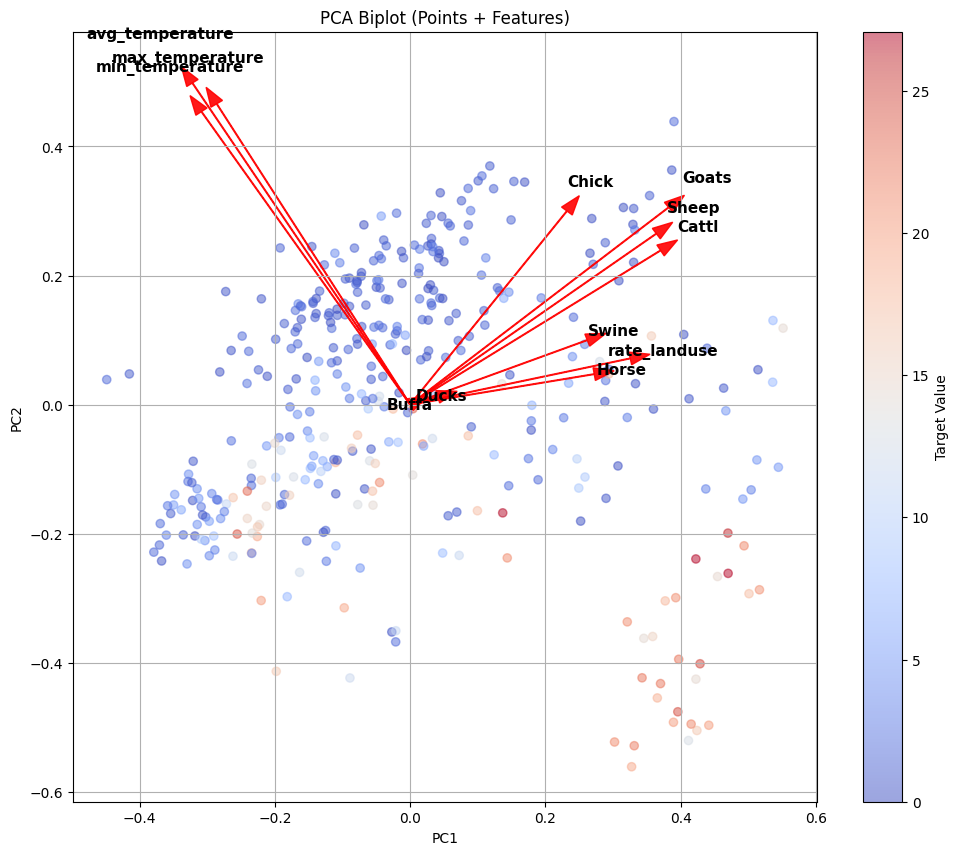

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def biplot(score, coeff, labels=None, y=None):
    """
    score: pca.fit_transform()의 결과 (PC 점수)
    coeff: pca.components_ (고유벡터, 로딩값)
    labels: 원래 변수들의 이름 (columns)
    y: 데이터의 라벨 (색깔 구분을 위해 사용, 없으면 None)
    """
    xs = score[:, 0] # PC1
    ys = score[:, 1] # PC2
    n = coeff.shape[1] # 변수의 개수
    
    # 스케일링 (화살표가 점들과 비슷한 크기로 보이게 조정)
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    
    plt.figure(figsize=(12, 10))
    
    # Scatter Plot
    if y is not None:
        # 라벨이 있으면 색깔로 구분
        scatter = plt.scatter(xs * scalex, ys * scaley, c=y, cmap='coolwarm', alpha=0.5)
        plt.colorbar(scatter, label='Target Value')
    else:
        plt.scatter(xs * scalex, ys * scaley, alpha=0.5)
        
    # 화살표(변수) 그리기
    for i in range(n):
        # 화살표 그리기
        plt.arrow(0, 0, coeff[0, i], coeff[1, i], color='r', alpha=0.9, head_width=0.02) 
        
        # 변수 이름 텍스트 출력 (조금 떨어뜨려서)
        plt.text(coeff[0, i]* 1.15, coeff[1, i] * 1.15, labels[i], 
                 color='black', ha='center', va='center', fontsize=11, weight='bold')

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid()
    plt.title("PCA Biplot (Points + Features)")

# pca 모델은 이미 fit 되어 있다고 가정 (n_components=2 이상)
pca_result = pca.transform(X_train) 

biplot(pca_result, pca.components_, labels=X_train.columns, y=y_train)
plt.show()

### 3.5 3D 산점도

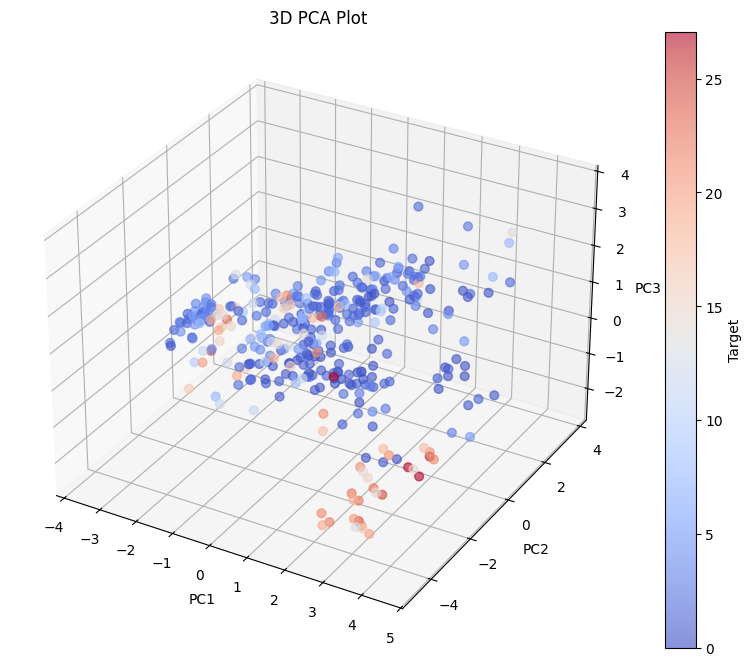

In [11]:
# 3D 산점도
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 라벨에 따라 색상 다르게 (y_train이 연속형이면 c=y_train, 범주형이면 전처리 필요)
sc = ax.scatter(finalDf['principal component1'], 
                finalDf['principal component2'], 
                finalDf['3'], # PC3 컬럼명 확인 필요
                c=y_train, 
                cmap='coolwarm', 
                s=40, alpha=0.6)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.colorbar(sc, label='Target')
plt.title('3D PCA Plot')
plt.show()

### 3.6 PCA 이후 outlier 찾기

=== 이상치 탐지 결과 (상위 1%, 기준점: 5.4098) ===
총 4개의 이상치가 발견되었습니다.


,principal component1,principal component2,3,4,5,6,7,8,9,10,infection_rate,pca_distance
45,3.427469,-4.304476,-1.879392,0.302131,0.822335,0.385630,-0.057746,-0.025232,-0.028038,-0.018769,16.504854,5.502369
83,3.569327,-4.235098,-2.027709,0.130046,0.761893,0.548687,-0.037683,-0.254257,-0.107461,0.201967,19.971469,5.538606
133,3.326457,-4.436955,-1.809403,0.357854,0.463753,0.271405,0.355972,-0.216303,-0.186705,-0.087375,12.857143,5.545439
344,2.646755,-4.782932,-1.795910,0.028888,0.204534,0.533651,-0.258061,-0.082213,-0.094297,-0.027943,19.215686,5.466420


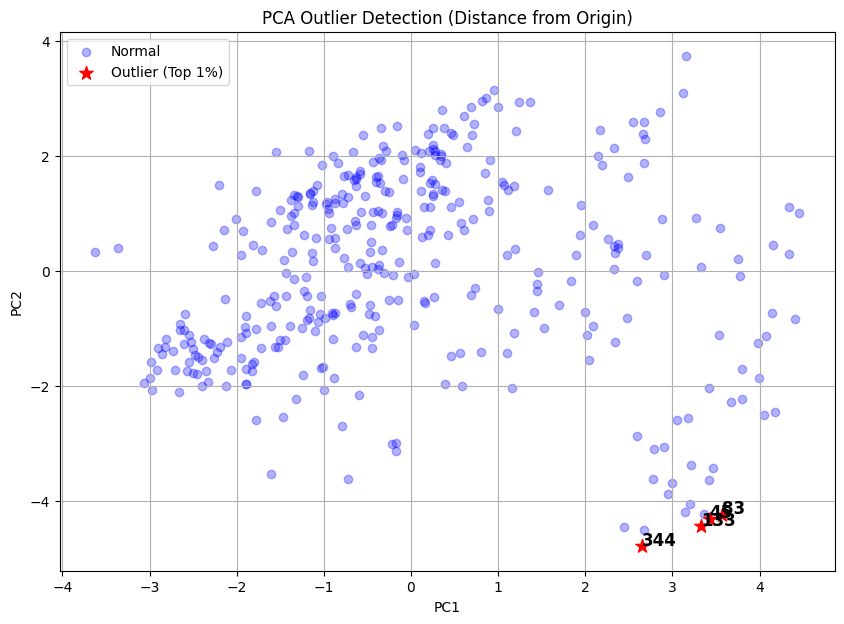

In [12]:
# 1. 원점으로부터의 거리(Score Distance) 계산
# finalDf에 'principal component1', 'principal component2' 컬럼이 있다고 가정
# 만약 PC가 더 많다면 모든 PC를 제곱해서 더해도 됩니다.
finalDf['pca_distance'] = np.sqrt(
    finalDf['principal component1']**2 + finalDf['principal component2']**2
)

# 2. 상위 1% 임계값(Threshold) 계산
threshold = np.percentile(finalDf['pca_distance'], 99) # 99번째 백분위수

# 3. 이상치 데이터 추출
outliers = finalDf[finalDf['pca_distance'] > threshold]

print(f"=== 이상치 탐지 결과 (상위 1%, 기준점: {threshold:.4f}) ===")
print(f"총 {len(outliers)}개의 이상치가 발견되었습니다.")
display(outliers) # 이상치 데이터프레임 확인 (인덱스나 다른 변수 값을 확인하세요)

# -------------------------------------------------------
# 4. 시각화: 정상 데이터 vs 이상치
plt.figure(figsize=(10, 7))

# 정상 데이터 (파란색, 흐리게)
normal_data = finalDf[finalDf['pca_distance'] <= threshold]
plt.scatter(normal_data['principal component1'], normal_data['principal component2'], 
            c='blue', alpha=0.3, label='Normal')

# 이상치 데이터 (빨간색, 진하게, 크게)
plt.scatter(outliers['principal component1'], outliers['principal component2'], 
            c='red', s=100, marker='*', label='Outlier (Top 1%)')

# 이상치에 인덱스(번호) 달아주기 (누군지 식별용)
for i in outliers.index:
    plt.text(outliers.loc[i, 'principal component1'], 
             outliers.loc[i, 'principal component2'] + 0.02, # 살짝 위에 글씨 쓰기
             str(i), # 인덱스 번호 출력 (지역명 등이 있다면 그걸 출력)
             fontsize=12, color='black', fontweight='bold')

plt.title('PCA Outlier Detection (Distance from Origin)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid()
plt.show()

In [15]:
rawDf = pd.concat([X_train, y_train], axis=1)

In [ ]:
# 이상치들의 인덱스 번호 가져오기
outlier_indices = outliers.index

# 원본 데이터에서 해당 인덱스 조회
# 기본적인 scale은 된 상태.. scale 이후에 train, test를 나눠서 train 데이터를 이용하려면 scale된 버전 밖에 없음
original_outliers = rawDf.loc[outlier_indices]

# 평균값과 비교해보기
comparison_df = pd.concat([original_outliers, rawDf.mean().to_frame().T])
comparison_df.index = list(outlier_indices) + ['Average'] # 인덱스 이름 붙여주기

print("--- 이상치 원본 값 vs 전체 평균 비교 ---")
display(comparison_df)

=== 이상치 원본 값 vs 전체 평균 비교 ===


,max_temperature,min_temperature,avg_temperature,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse,infection_rate
45,-0.339110,0.139625,-0.255082,0.0,-0.810332,-0.330511,-0.333479,0.068987,-0.527633,-1.064527,0.186068,-0.711198,6.378601
83,-0.409277,0.542346,0.064937,0.0,-1.329492,-0.217837,-0.387296,-1.315362,-0.538774,-1.208817,-0.220215,-0.220112,1.876877
133,0.055829,0.068687,0.071426,0.0,0.563239,1.104541,-0.387296,0.513622,-0.340817,-0.115221,-0.276699,0.853433,2.205882
344,0.362306,0.805989,0.775458,0.0,0.906690,1.217471,-0.387296,1.057968,3.980671,1.371187,0.366755,0.421528,0.385604
Average,-0.023284,-0.031024,-0.027463,0.0,0.018604,0.007875,-0.032156,0.020024,0.013871,0.038337,0.005235,-0.031036,5.521895
